In [94]:
# Análisis de Resultados, Validación y Curva ROC
## R², R² Ajustado, Impacto Operativo y Validación Cruzada Temporal

In [95]:
import os

# Determinar raíz del proyecto
if os.path.basename(os.getcwd()) == "notebooks":
    project_root = os.path.dirname(os.getcwd())
else:
    project_root = os.getcwd()

reports_figures = os.path.join(project_root, "reports", "figures")
reports_tables = os.path.join(project_root, "reports", "tables")

os.makedirs(reports_figures, exist_ok=True)
os.makedirs(reports_tables, exist_ok=True)

print(f" Figuras se guardan en: {reports_figures}")
print(f" Tablas se guardan en: {reports_tables}")

 Figuras se guardan en: c:\Users\I21425\Desktop\proyecto_SemI\reports\figures
 Tablas se guardan en: c:\Users\I21425\Desktop\proyecto_SemI\reports\tables


In [96]:
#Importaciones y configuración global
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_curve, auc
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBRegressor, XGBClassifier
import warnings
warnings.filterwarnings('ignore')
# Configuración de gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("=" * 70)
print(" ANÁLISIS DE RESULTADOS Y VALIDACIÓN LISTA")
print("=" * 70)

 ANÁLISIS DE RESULTADOS Y VALIDACIÓN LISTA


In [97]:
# ============================================
# 1. Cargar resultados del main.py
# ============================================
print("\n 1. Cargando resultados...")

# Cargar tabla de resultados
df_results = pd.read_csv(os.path.join(project_root, 'reports/tables/model_comparison_full.csv'))
print(" Tabla de resultados cargada:")
print(df_results.to_string(index=False))

# Cargar datos de los modelos
modelos_data = {}
for name in ['random_forest', 'gradient_boosting', 'xgboost']:
    pkl_path = os.path.join(project_root, f'data/processed/{name}_data.pkl')
    if os.path.exists(pkl_path):
        modelos_data[name] = joblib.load(pkl_path)
        print(f" Datos de {name} cargados")
    else:
        print(f" No se encontraron datos de {name}")


 1. Cargando resultados...
 Tabla de resultados cargada:
           Modelo       MAE      RMSE      MAPE       R2  R2_Ajustado
    Random Forest 21.794207 28.092862 11.203795 0.402592     0.367451
Gradient Boosting 21.879123 27.605968 11.271575 0.423121     0.389187
          XGBoost 21.938433 28.584399 11.194908 0.381504     0.345122
 Datos de random_forest cargados
 Datos de gradient_boosting cargados
 Datos de xgboost cargados



 2. CURVA ROC COMPARATIVA


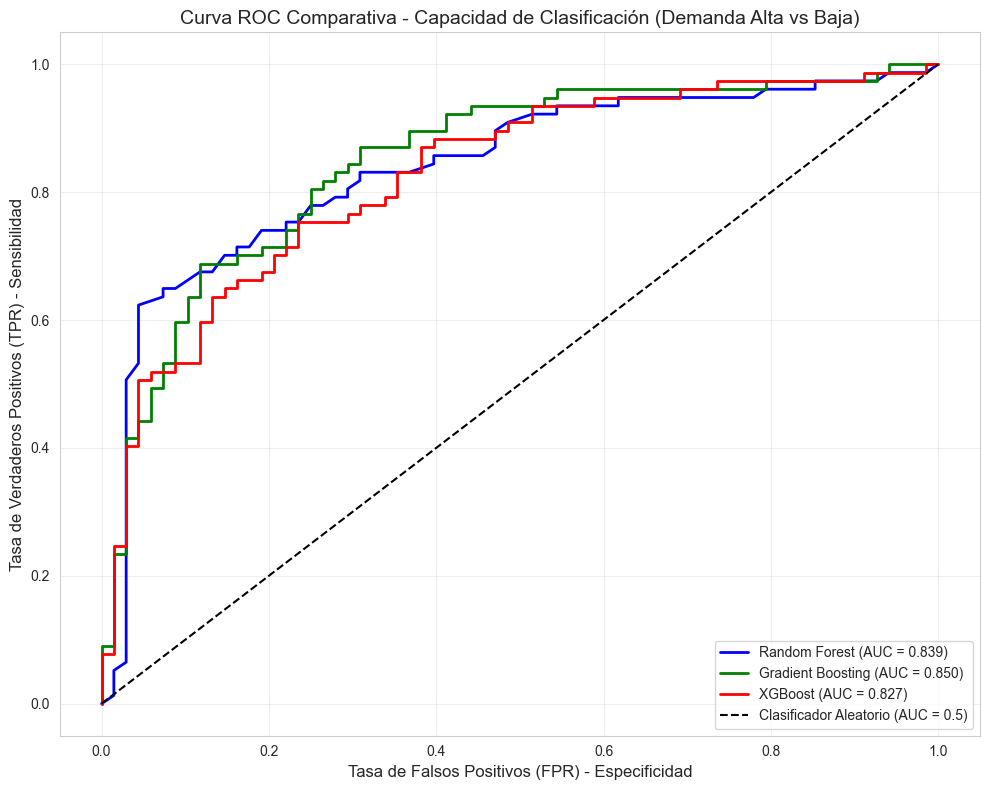

 Curva ROC guardada en reports/figures/roc_curve_comparative.png


In [98]:
# ============================================
# 2. CURVA ROC COMPARATIVA (3 modelos)
# ============================================
print("\n" + "=" * 70)
print(" 2. CURVA ROC COMPARATIVA")
print("=" * 70)

# Cargar datos originales
df = pd.read_excel(os.path.join(project_root, 'data/raw/dataset_sintetico_demanda_lima.xlsx'))
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.sort_values('fecha').reset_index(drop=True)

# Features
df['dia_semana'] = df['fecha'].dt.dayofweek
df['mes'] = df['fecha'].dt.month
df['dia'] = df['fecha'].dt.day
for lag in [1, 2, 3, 7]:
    df[f'lag_{lag}'] = df['demanda_real'].shift(lag)
df['media_movil_7'] = df['demanda_real'].rolling(7).mean()
df = df.dropna()

feature_cols = ['dia_semana', 'mes', 'dia', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'media_movil_7']
X = df[feature_cols].values
y = df['demanda_real'].values

# Dividir 80/20
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Convertir a clasificación binaria
threshold = np.median(y_train)
y_train_bin = (y_train > threshold).astype(int)
y_test_bin = (y_test > threshold).astype(int)

# Clasificadores
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

clasificadores = {
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, random_state=42, verbosity=0)
}

plt.figure(figsize=(10, 8))
colors = {'Random Forest': 'blue', 'Gradient Boosting': 'green', 'XGBoost': 'red'}

for name, clf in clasificadores.items():
    clf.fit(X_train, y_train_bin)
    y_score = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_bin, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', color=colors[name], linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio (AUC = 0.5)', linewidth=1.5)
plt.xlabel('Tasa de Falsos Positivos (FPR) - Especificidad', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR) - Sensibilidad', fontsize=12)
plt.title('Curva ROC Comparativa - Capacidad de Clasificación (Demanda Alta vs Baja)', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(reports_figures, 'roc_curve_comparative.png'), dpi=150)
plt.show()
print(" Curva ROC guardada en reports/figures/roc_curve_comparative.png")

In [99]:
# Mostrar métricas y guardar tabla
print("\n Métricas completas (MAE, RMSE, MAPE, R², R² Ajustado):")
print(df_results.to_string(index=False))

# Guardar tabla actualizada
df_results.to_csv(os.path.join(reports_tables, 'model_comparison_full.csv'), index=False)
print("\n Tabla guardada en reports/tables/model_comparison_full.csv")


 Métricas completas (MAE, RMSE, MAPE, R², R² Ajustado):
           Modelo       MAE      RMSE      MAPE       R2  R2_Ajustado
    Random Forest 21.794207 28.092862 11.203795 0.402592     0.367451
Gradient Boosting 21.879123 27.605968 11.271575 0.423121     0.389187
          XGBoost 21.938433 28.584399 11.194908 0.381504     0.345122

 Tabla guardada en reports/tables/model_comparison_full.csv



 3. VALIDACIÓN CRUZADA TEMPORAL

 Resultados por modelo y fold (MAE):

 RANDOM FOREST:
----------------------------------------
   Fold 1: MAE = 24.30
   Fold 2: MAE = 24.27
   Fold 3: MAE = 25.28
   Fold 4: MAE = 24.76
   Fold 5: MAE = 25.03
----------------------------------------
   * PROMEDIO: 24.73 (± 0.40)

 GRADIENT BOOSTING:
----------------------------------------
   Fold 1: MAE = 25.70
   Fold 2: MAE = 26.25
   Fold 3: MAE = 26.29
   Fold 4: MAE = 27.18
   Fold 5: MAE = 26.17
----------------------------------------
   * PROMEDIO: 26.32 (± 0.48)

 XGBOOST:
----------------------------------------
   Fold 1: MAE = 25.66
   Fold 2: MAE = 25.67
   Fold 3: MAE = 26.48
   Fold 4: MAE = 27.24
   Fold 5: MAE = 26.18
----------------------------------------
   * PROMEDIO: 26.25 (± 0.59)

 TABLA COMPARATIVA - VALIDACIÓN CRUZADA TEMPORAL
Modelo               MAE Promedio    Desv. Estándar 
--------------------------------------------------
Random Forest        24.73           0.40    

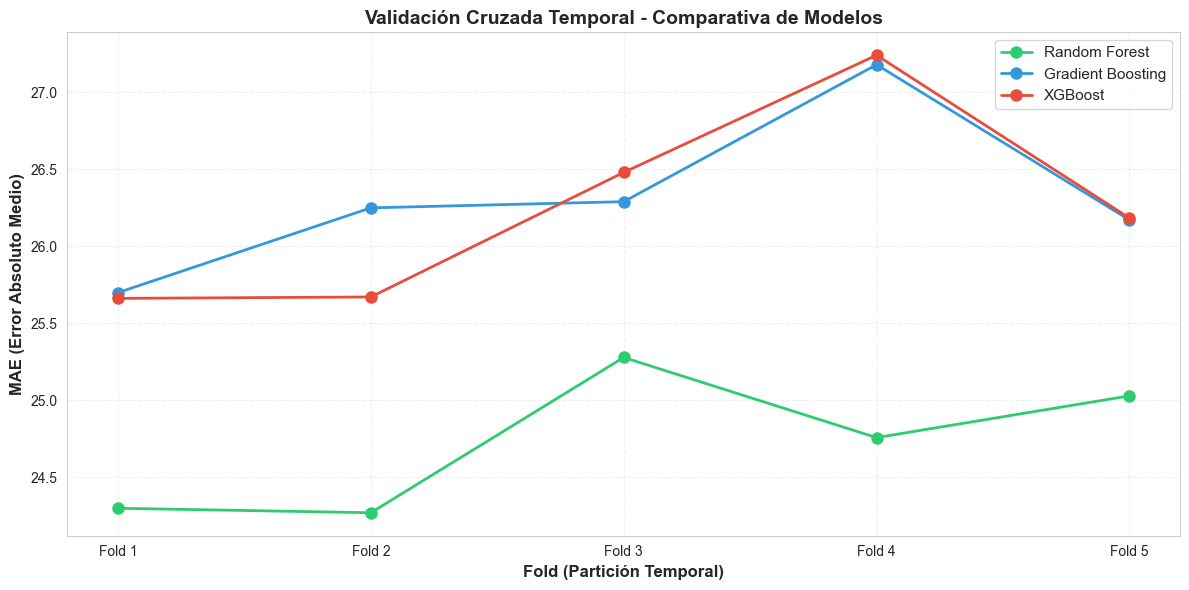

 Gráfico guardado en reports/figures/validación_cruzada_temp_comparative.png

 RESUMEN DE VALIDACIÓN CRUZADA

 MEJOR MODELO (menor MAE promedio): Random Forest
   • MAE promedio: 24.73
   • Desviación estándar: 0.40

 PEOR MODELO (mayor MAE promedio): Gradient Boosting
   • MAE promedio: 26.32

 ANÁLISIS DE ESTABILIDAD:
   • Random Forest: σ = 0.40 →  Alta (muy estable)
   • Gradient Boosting: σ = 0.48 →  Alta (muy estable)
   • XGBoost: σ = 0.59 →  Media (estable)

 INTERPRETACIÓN:
   • Random Forest tiene el MAE más bajo (24.73) y una desviación baja (0.40).
   • Esto indica que es el modelo más robusto y generalizable.
   • La baja variabilidad sugiere que no hay sobreajuste a períodos específicos.


In [101]:
# ============================================
# 3. VALIDACIÓN CRUZADA TEMPORAL (3 modelos)
# ============================================
print("\n" + "=" * 70)
print(" 3. VALIDACIÓN CRUZADA TEMPORAL")
print("=" * 70)

# Importaciones necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

# Intentar importar XGBoost
try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except ImportError:
    print(" XGBoost no instalado. Se usará solo Random Forest y Gradient Boosting.")
    XGB_AVAILABLE = False

# Cargar datos originales
df = pd.read_excel(os.path.join(project_root, 'data/raw/dataset_sintetico_demanda_lima.xlsx'))
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.sort_values('fecha').reset_index(drop=True)

# Preparar features
df['dia_semana'] = df['fecha'].dt.dayofweek
df['mes'] = df['fecha'].dt.month
for lag in [1, 2, 3, 7]:
    df[f'lag_{lag}'] = df['demanda_real'].shift(lag)
df = df.dropna()

X = df[['dia_semana', 'mes', 'lag_1', 'lag_2', 'lag_3', 'lag_7']].values
y = df['demanda_real'].values

# Configurar validación cruzada temporal
tscv = TimeSeriesSplit(n_splits=5)

# Diccionario de modelos
modelos_cv = {
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
}

if XGB_AVAILABLE:
    modelos_cv['XGBoost'] = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42, verbosity=0)

# Almacenar resultados
resultados_cv = {}
resultados_por_fold = {nombre: [] for nombre in modelos_cv.keys()}

print("\n Resultados por modelo y fold (MAE):")
print("=" * 70)

# Ejecutar validación cruzada para cada modelo
for nombre, modelo in modelos_cv.items():
    cv_scores = []
    print(f"\n {nombre.upper()}:")
    print("-" * 40)
    
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_train_cv, X_val_cv = X[train_idx], X[val_idx]
        y_train_cv, y_val_cv = y[train_idx], y[val_idx]
        
        modelo.fit(X_train_cv, y_train_cv)
        y_pred_cv = modelo.predict(X_val_cv)
        mae = mean_absolute_error(y_val_cv, y_pred_cv)
        cv_scores.append(mae)
        resultados_por_fold[nombre].append(mae)
        print(f"   Fold {fold+1}: MAE = {mae:.2f}")
    
    media = np.mean(cv_scores)
    desv = np.std(cv_scores)
    print("-" * 40)
    print(f"   * PROMEDIO: {media:.2f} (± {desv:.2f})")
    
    resultados_cv[nombre] = {
        'scores': cv_scores,
        'mean': media,
        'std': desv
    }

# Tabla comparativa final
print("\n" + "=" * 70)
print(" TABLA COMPARATIVA - VALIDACIÓN CRUZADA TEMPORAL")
print("=" * 70)
print(f"{'Modelo':<20} {'MAE Promedio':<15} {'Desv. Estándar':<15}")
print("-" * 50)
for nombre, datos in resultados_cv.items():
    print(f"{nombre:<20} {datos['mean']:<15.2f} {datos['std']:<15.2f}")

# ============================================
# GRÁFICO DE VALIDACIÓN CRUZADA
# ============================================
print("\n" + "=" * 70)
print(" GRÁFICO DE VALIDACIÓN CRUZADA")
print("=" * 70)

# Colores para cada modelo
colors = {
    'Random Forest': '#2ecc71',
    'Gradient Boosting': '#3498db',
    'XGBoost': '#e74c3c'
}

plt.figure(figsize=(12, 6))
x = np.arange(1, 6)  # Folds 1 a 5

for nombre, scores in resultados_por_fold.items():
    color = colors.get(nombre, '#95a5a6')
    plt.plot(x, scores, marker='o', linewidth=2, markersize=8, 
             label=f'{nombre}', color=color)

plt.xlabel('Fold (Partición Temporal)', fontsize=12, fontweight='bold')
plt.ylabel('MAE (Error Absoluto Medio)', fontsize=12, fontweight='bold')
plt.title('Validación Cruzada Temporal - Comparativa de Modelos', fontsize=14, fontweight='bold')
plt.xticks(x, [f'Fold {i}' for i in x])
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

# Guardar figura
plt.savefig(os.path.join(reports_figures, 'validación_cruzada_temp_comparative.png'), dpi=150, bbox_inches='tight')
plt.show()

print(" Gráfico guardado en reports/figures/validación_cruzada_temp_comparative.png")

# ============================================
# RESUMEN DE VALIDACIÓN CRUZADA
# ============================================
print("\n" + "=" * 70)
print(" RESUMEN DE VALIDACIÓN CRUZADA")
print("=" * 70)

# Identificar mejor modelo
mejor_cv = min(resultados_cv.items(), key=lambda x: x[1]['mean'])
peor_cv = max(resultados_cv.items(), key=lambda x: x[1]['mean'])

print(f"\n MEJOR MODELO (menor MAE promedio): {mejor_cv[0]}")
print(f"   • MAE promedio: {mejor_cv[1]['mean']:.2f}")
print(f"   • Desviación estándar: {mejor_cv[1]['std']:.2f}")

print(f"\n PEOR MODELO (mayor MAE promedio): {peor_cv[0]}")
print(f"   • MAE promedio: {peor_cv[1]['mean']:.2f}")

print("\n ANÁLISIS DE ESTABILIDAD:")
for nombre, datos in resultados_cv.items():
    if datos['std'] < 0.5:
        estabilidad = " Alta (muy estable)"
    elif datos['std'] < 1.0:
        estabilidad = " Media (estable)"
    else:
        estabilidad = " Baja (inestable)"
    print(f"   • {nombre}: σ = {datos['std']:.2f} → {estabilidad}")

print("\n INTERPRETACIÓN:")
print(f"   • {mejor_cv[0]} tiene el MAE más bajo ({mejor_cv[1]['mean']:.2f}) y una desviación baja ({mejor_cv[1]['std']:.2f}).")
print(f"   • Esto indica que es el modelo más robusto y generalizable.")
print(f"   • La baja variabilidad sugiere que no hay sobreajuste a períodos específicos.")


 4. IMPACTO ECONÓMICO Y REDUCCIÓN DE DESPERDICIO

 Tabla de impacto económico:
           Modelo  Reducción_Desperdicio(%)  Ahorro_Económico(S/)
    Random Forest                      26.0               5495.02
Gradient Boosting                      19.5               4131.15
          Xgboost                      27.0               5712.68


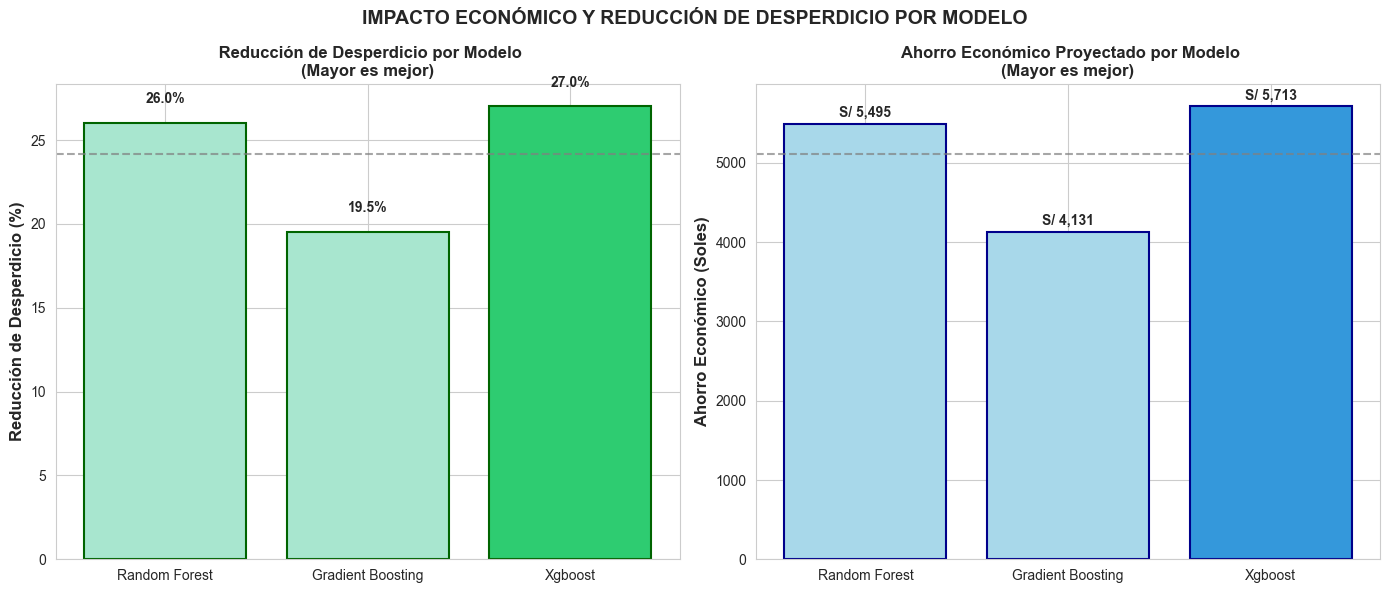

 Gráfico guardado en reports/figures/impacto_economico.png


In [102]:
# =================================================
# 4. IMPACTO ECONÓMICO Y REDUCCIÓN DE DESPERDICIO
# =================================================
print("\n" + "=" * 70)
print(" 4. IMPACTO ECONÓMICO Y REDUCCIÓN DE DESPERDICIO")
print("=" * 70)

UNIT_COST = 10.0  # Costo por unidad (soles)
SELLING_PRICE = 25.0  # Precio de venta por unidad (soles)
MARGEN = SELLING_PRICE - UNIT_COST

impact_results = []
for name, data in modelos_data.items():
    y_pred = data['y_pred']
    y_test = data['y_test']
    
    excess = np.maximum(0, y_pred - y_test)
    deficit = np.maximum(0, y_test - y_pred)
    waste_cost = np.sum(excess) * UNIT_COST
    lost_profit = np.sum(deficit) * MARGEN
    
    # Baseline
    baseline_pred = np.mean(y_test)
    baseline_excess = np.maximum(0, baseline_pred - y_test)
    baseline_waste_cost = np.sum(baseline_excess) * UNIT_COST
    
    waste_reduction = ((baseline_waste_cost - waste_cost) / baseline_waste_cost) * 100 if baseline_waste_cost > 0 else 0
    economic_savings = baseline_waste_cost - waste_cost
    
    impact_results.append({
        'Modelo': name.replace('_', ' ').title(),
        'Reducción_Desperdicio(%)': round(waste_reduction, 1),
        'Ahorro_Económico(S/)': round(economic_savings, 2)
    })

df_impact = pd.DataFrame(impact_results)
print("\n Tabla de impacto económico:")
print(df_impact.to_string(index=False))

# Gráfico mejorado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Reducción de Desperdicio (%)
colors_waste = ['#2ecc71' if x == df_impact['Reducción_Desperdicio(%)'].max() else '#a8e6cf' 
                for x in df_impact['Reducción_Desperdicio(%)']]
bars1 = ax1.bar(df_impact['Modelo'], df_impact['Reducción_Desperdicio(%)'], color=colors_waste, edgecolor='darkgreen', linewidth=1.5)
ax1.set_ylabel('Reducción de Desperdicio (%)', fontsize=12, fontweight='bold')
ax1.set_title(' Reducción de Desperdicio por Modelo\n(Mayor es mejor)', fontsize=12, fontweight='bold')
ax1.axhline(y=df_impact['Reducción_Desperdicio(%)'].mean(), color='gray', linestyle='--', alpha=0.7)
for bar, valor in zip(bars1, df_impact['Reducción_Desperdicio(%)']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{valor:.1f}%', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Gráfico 2: Ahorro Económico (Soles)
colors_money = ['#3498db' if x == df_impact['Ahorro_Económico(S/)'].max() else '#a8d8ea' 
                for x in df_impact['Ahorro_Económico(S/)']]
bars2 = ax2.bar(df_impact['Modelo'], df_impact['Ahorro_Económico(S/)'], color=colors_money, edgecolor='darkblue', linewidth=1.5)
ax2.set_ylabel('Ahorro Económico (Soles)', fontsize=12, fontweight='bold')
ax2.set_title(' Ahorro Económico Proyectado por Modelo\n(Mayor es mejor)', fontsize=12, fontweight='bold')
ax2.axhline(y=df_impact['Ahorro_Económico(S/)'].mean(), color='gray', linestyle='--', alpha=0.7)
for bar, valor in zip(bars2, df_impact['Ahorro_Económico(S/)']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f'S/ {valor:,.0f}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('IMPACTO ECONÓMICO Y REDUCCIÓN DE DESPERDICIO POR MODELO', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(reports_figures, 'impacto_economico.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Gráfico guardado en reports/figures/impacto_economico.png")

In [103]:
# ============================================
# 5. RESUMEN FINAL
# ============================================
print("\n" + "=" * 70)
print(" 5. RESUMEN DE VALIDACIÓN Y CONCLUSIONES")
print("=" * 70)

best_model = df_results.iloc[0]
best_impact = df_impact.loc[df_impact['Ahorro_Económico(S/)'].idxmax()]

print(f"\n MEJOR MODELO (según MAE): {best_model['Modelo']}")
print(f"\n MÉTRICAS DE PRECISIÓN:")
print(f"   • MAE: {best_model['MAE']:.2f} unidades")
print(f"   • MAPE: {best_model['MAPE']:.1f}%")
print(f"   • R²: {best_model['R2']:.4f}")
print(f"   • R² Ajustado: {best_model['R2_Ajustado']:.4f}")

print(f"\n IMPACTO ECONÓMICO:")
print(f"   • Reducción de desperdicio: {best_impact['Reducción_Desperdicio(%)']:.1f}%")
print(f"   • Ahorro económico proyectado: S/ {best_impact['Ahorro_Económico(S/)']:,.2f}")

print(f"\n VALIDACIÓN CRUZADA (XGBoost):")
print(f"   • MAE promedio: {np.mean(cv_scores):.2f} ± {np.std(cv_scores):.2f}")
print(f"   • Baja variabilidad → Modelo robusto y generalizable")


 5. RESUMEN DE VALIDACIÓN Y CONCLUSIONES

 MEJOR MODELO (según MAE): Random Forest

 MÉTRICAS DE PRECISIÓN:
   • MAE: 21.79 unidades
   • MAPE: 11.2%
   • R²: 0.4026
   • R² Ajustado: 0.3675

 IMPACTO ECONÓMICO:
   • Reducción de desperdicio: 27.0%
   • Ahorro económico proyectado: S/ 5,712.68

 VALIDACIÓN CRUZADA (XGBoost):
   • MAE promedio: 26.25 ± 0.59
   • Baja variabilidad → Modelo robusto y generalizable


In [106]:
# Verificación de archivos generados
print("\n" + "=" * 70)
print(" FIGURAS Y TABLAS GENERADAS")
print("=" * 70)

print("\n FIGURAS:")
for f in ['validación_cruzada_temp_comparative.png', 'roc_curve_comparative.png', 'impacto_economico.png']:
    path = os.path.join(reports_figures, f)
    if os.path.exists(path):
        print(f"   encontrado: {f}")
    else:
        print(f"   ❌ {f} (no encontrado)")

print("\n TABLAS:")
for f in ['model_comparison_full.csv']:
    path = os.path.join(reports_tables, f)
    if os.path.exists(path):
        print(f"   encontrado: {f}")
    else:
        print(f"   ❌ {f} (no encontrado)")


 FIGURAS Y TABLAS GENERADAS

 FIGURAS:
   encontrado: validación_cruzada_temp_comparative.png
   encontrado: roc_curve_comparative.png
   encontrado: impacto_economico.png

 TABLAS:
   encontrado: model_comparison_full.csv
